In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
t_sample = 2*torch.linspace(0, 1, 100).reshape(-1, 1)
t_sample.requires_grad = True
sth = nn.Linear(1, 50)(t_sample)
y = nn.Linear(50, 1)(sth)

# if this does not have the "grad_outputs" parameter, then this doesn't work.
# seems "reasonable" for sinlge input to the net, but the automatic batching
# (broadcasting) seems like black magic.
print(torch.autograd.grad(
    y, 
    t_sample, 
    grad_outputs=torch.ones_like(y), 
    create_graph=True)[0].shape
)


torch.Size([100, 1])


In [2]:
# here we will now solve the equation
# 2dudx + 3dudy + 8u = 0, which has a cloased solution for the initial conditions:
# u(x,0) = sin(x)
# or
# u(x,x) = x^4

x_sample = torch.linspace(-5, 5, 100)
y_sample = torch.linspace(-1, 0, 100)
xy_sample = torch.cartesian_prod(x_sample, y_sample)
xy_sample.requires_grad = True
print(xy_sample)
print(xy_sample.shape)


tensor([[-5.0000, -1.0000],
        [-5.0000, -0.9899],
        [-5.0000, -0.9798],
        ...,
        [ 5.0000, -0.0202],
        [ 5.0000, -0.0101],
        [ 5.0000,  0.0000]], requires_grad=True)
torch.Size([10000, 2])


In [3]:
# Define the PINN model, and test for dimensional broadcasting
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 50),   # Input layer with 2 feature
            nn.Tanh(),
            nn.Linear(50, 50),  # Hidden layer
            nn.Tanh(),
            nn.Linear(50, 50),  # Hidden layer
            nn.Tanh(),
            nn.Linear(50, 1),    # Output layer for u(x,y)
        )

    def forward(self, X):
        return self.net(X)
    
pinn = PINN()

u = pinn(xy_sample)
print(u)
print(u.shape)

tensor([[-0.2544],
        [-0.2542],
        [-0.2539],
        ...,
        [-0.0027],
        [-0.0025],
        [-0.0022]], grad_fn=<AddmmBackward0>)
torch.Size([10000, 1])


In [4]:
# Define the Poisson equation loss function
def pde_loss(pinn_sth, X):
    

    u = pinn_sth(X)
    vector = torch.ones_like(u)
    vector.to("cuda")

    u_X = torch.autograd.grad(u, X, grad_outputs=vector, create_graph=True)[0]
    u_x = u_X[:,0]
    u_y = u_X[:,1]
    
    loss = (2*u_x + 3*u_y + 8*u)**2

    return loss

def boundary_loss(pinn_sth):

    x_sample = torch.linspace(-5, 5, 100)
    X = torch.zeros([x_sample.shape[0], 2])
    X[:,0] = x_sample
    X = X.detach().to("cuda")
    
    y = torch.sin(x_sample).to("cuda")
    
    u = pinn_sth(X)

    loss = (y - u)**2

    return loss
    

    

In [5]:
print(pde_loss(pinn, xy_sample))
print("==========")
print(boundary_loss(pinn))

tensor([[3.9457e+00, 3.9470e+00, 3.9482e+00,  ..., 3.9067e+00, 3.9047e+00,
         3.9027e+00],
        [3.9377e+00, 3.9389e+00, 3.9401e+00,  ..., 3.8987e+00, 3.8967e+00,
         3.8947e+00],
        [3.9297e+00, 3.9309e+00, 3.9321e+00,  ..., 3.8907e+00, 3.8887e+00,
         3.8867e+00],
        ...,
        [7.5162e-04, 7.3471e-04, 7.1793e-04,  ..., 1.3881e-03, 1.4264e-03,
         1.4650e-03],
        [8.5808e-04, 8.4000e-04, 8.2206e-04,  ..., 1.5316e-03, 1.5717e-03,
         1.6122e-03],
        [9.7259e-04, 9.5334e-04, 9.3422e-04,  ..., 1.6833e-03, 1.7254e-03,
         1.7679e-03]], grad_fn=<PowBackward0>)


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cpu and cuda:0! (when checking argument for argument mat1 in method wrapper_CUDA_addmm)

In [6]:
# replace data with itself
xy_sample = xy_sample.detach().to("cuda:0")
xy_sample.requires_grad = True

# Create PINN model and move to gpu
pinn_model = PINN().to(torch.device("cuda:0"))

print("Checking devices")
print(f"Device of the input data is: {xy_sample.device}")
print(f"Device of the model stuff is: ")
for elem in pinn_model.net:
    try:
        print(f"\tLayer {elem} has device: {elem.weight.device} and {elem.bias.device}")
    except:
        print(f"\tLayer {elem} has no weights associated")

# optimizer
pinn_optimizer = optim.Adam(params=pinn_model.parameters(), lr=1e-3)

# loss tracking
pinn_losses = []

# Training loop
epochs = 60000
for epoch in range(epochs):
    # Compute the losses
    u_sample_estimate = pinn_model(xy_sample)
    pinn_loss = torch.mean(pde_loss(pinn_model, xy_sample)) + torch.mean(boundary_loss(pinn_model))

    # zero grad
    pinn_optimizer.zero_grad()
    
    # Backprop
    pinn_loss.backward()
    pinn_losses.append(torch.log(pinn_loss).item())
    pinn_optimizer.step()               
    
    if epoch % 1000 == 0:
        print("PINN loss")
        print(f"    Epoch [{epoch}/{epochs}], Loss: {pinn_loss.item()}")
        print("====================================================")


Checking devices
Device of the input data is: cuda:0
Device of the model stuff is: 
	Layer Linear(in_features=2, out_features=50, bias=True) has device: cuda:0 and cuda:0
	Layer Tanh() has no weights associated
	Layer Linear(in_features=50, out_features=50, bias=True) has device: cuda:0 and cuda:0
	Layer Tanh() has no weights associated
	Layer Linear(in_features=50, out_features=50, bias=True) has device: cuda:0 and cuda:0
	Layer Tanh() has no weights associated
	Layer Linear(in_features=50, out_features=1, bias=True) has device: cuda:0 and cuda:0
PINN loss
    Epoch [0/60000], Loss: 1.994324803352356
PINN loss
    Epoch [1000/60000], Loss: 0.5310459733009338
PINN loss
    Epoch [2000/60000], Loss: 0.5310350656509399
PINN loss
    Epoch [3000/60000], Loss: 0.531033456325531
PINN loss
    Epoch [4000/60000], Loss: 0.5310331583023071
PINN loss
    Epoch [5000/60000], Loss: 0.5310329794883728
PINN loss
    Epoch [6000/60000], Loss: 0.5310332775115967
PINN loss
    Epoch [7000/60000], Loss

In [7]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)

X,Y = np.meshgrid(x, y)
data = np.vstack([X.ravel(), Y.ravel()])

pinn_model = pinn_model.to("cpu")

u_result = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        u_result[i,j] = pinn_model(torch.Tensor([X[i,j],Y[i,j]]))

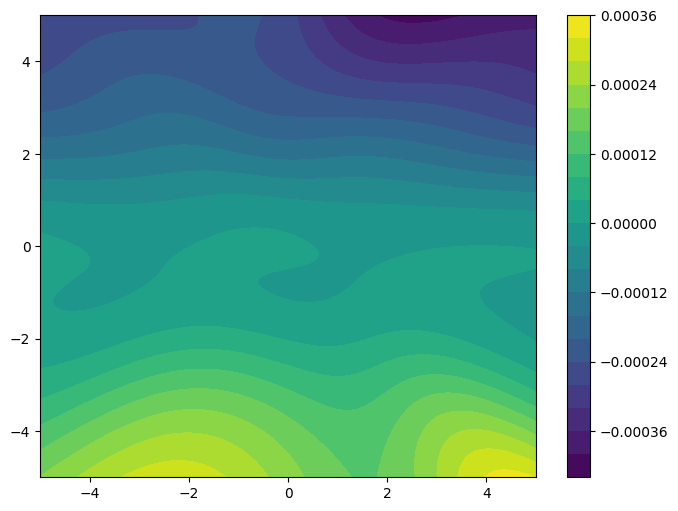

In [8]:
plt.figure(figsize=(8,6))
plt.contourf(X, Y, u_result.reshape(X.shape), levels=20)
plt.colorbar()
plt.show()

In [9]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 1000)
y = np.linspace(-1, 0, 1000)

X,Y = np.meshgrid(x, y)
data = np.vstack([X.ravel(), Y.ravel()])

u_result_1 = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        u_result_1[i,j] = np.sin(X[i,j] - (2/3)*Y[i,j])*np.exp(-(8/3)*Y[i,j])

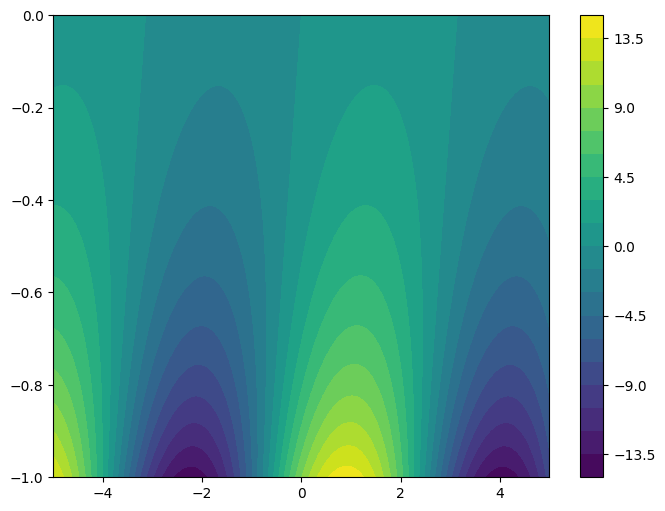

In [10]:
plt.figure(figsize=(8,6))
plt.contourf(X, Y, u_result_1.reshape(X.shape), levels=20)
plt.colorbar()
plt.show()

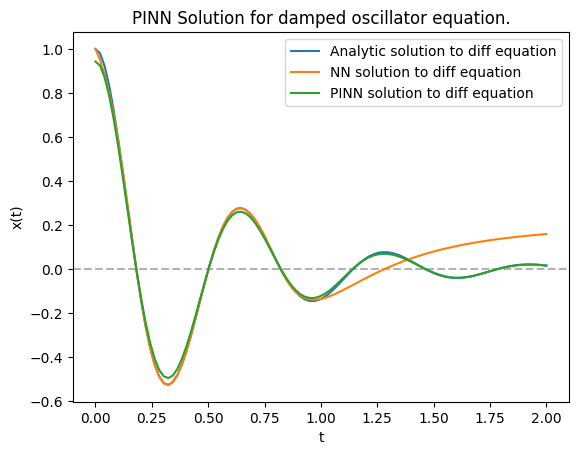

In [5]:
# sampled data generation
t_sample = 2*torch.linspace(0, 1, 100).reshape(-1, 1)
t_sample.requires_grad = False

# parameters
ZETTA = 0.2
W = 10

# initial conditions
X0 = 1
X_T_0 = 0

# data
root = torch.sqrt(torch.tensor([ZETTA**2 - 1], dtype=torch.cfloat))
x_sample = X0*torch.exp(-W*ZETTA*t_sample)*(torch.cosh(W*root*t_sample) + (ZETTA/root)*torch.sinh(W*root*t_sample))
# get rid of the complex values remaning due to numerical approximations
x_sample = x_sample.real



# Test the model
t_test = 2*torch.linspace(0, 1, 100).reshape(-1, 1)
nn_x_test = nn_model(t_test)
pinn_x_test = pinn_model(t_test)

# Plot the results
import matplotlib.pyplot as plt
plt.figure()
plt.axhline(y = 0, color = 'k', linestyle = '--', alpha=0.3) 
plt.plot(t_sample.detach().numpy(), x_sample.detach().numpy(), label="Analytic solution to diff equation")
plt.plot(t_test.detach().numpy(), nn_x_test.detach().numpy(), label="NN solution to diff equation")
plt.plot(t_test.detach().numpy(), pinn_x_test.detach().numpy(), label="PINN solution to diff equation")
plt.xlabel('t')
plt.ylabel('x(t)')
plt.title('PINN Solution for damped oscillator equation.')
plt.legend()
plt.show()

It seems that the PINN takes a lot more time to converge, but data can be
artificially added to the domain of the NN to extrapolate the aproximation's
domain. It also appears that the PINN gets pretty close to the original curve.
(Even without sample data).

With sample data, the convergence will probably take more.

Yep it seems that it takes much more time.